In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [96]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df

,임신횟수,혈당,혈압,피부두께,인슐린,BMI,가족력지표,나이,당뇨
0,6,148.0,72.0,35.0,159.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,95.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,159.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
713,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
714,2,122.0,70.0,27.0,95.0,36.8,0.340,27,0
715,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
716,1,126.0,60.0,32.0,159.0,30.1,0.349,47,1


In [97]:
data = df.iloc[:,:-1]
target = df.iloc[:,-1]

train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    test_size= 0.2,
    stratify=df.iloc[:,-1]
)

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)

In [98]:
print(train_scaled.shape)
print(test_scaled.shape)
print(train_target.shape)
print(test_target.shape)

(574, 8)
(144, 8)
(574,)
(144,)


In [99]:
x_train_data, x_valid_data, y_train_target, y_valid_target = train_test_split(
    train_scaled,
    train_target,
    random_state=42,
    test_size= 0.2,
    stratify=train_target
)

In [100]:
depth_list = range(1, 31)  # 깊이 1 ~ 30
dt_cross_val_scores = []

for depth in depth_list:
    dt = DecisionTreeClassifier(
        max_depth=depth,

        random_state=42
    )

    scores = cross_val_score(
        dt,
        x_train_data,
        y_train_target,
        cv=6,                  # 6-fold CV
        scoring='accuracy',
        n_jobs=-1
    )

    dt_cross_val_scores.append(scores.mean())

best_depth = depth_list[dt_cross_val_scores.index(max(dt_cross_val_scores))]
best_depth

3

In [101]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,

    random_state=42
).fit(x_train_data, y_train_target)
xdtTrain = []
xdtValid = []
for i in range(5):
    xdtTrain.append(dt.score(x_train_data, y_train_target))
    xdtValid.append(dt.score(x_valid_data, y_valid_target))
    print(dt.score(x_train_data, y_train_target))
    print(dt.score(x_valid_data, y_valid_target))

0.9172113289760349
0.8434782608695652
0.9172113289760349
0.8434782608695652
0.9172113289760349
0.8434782608695652
0.9172113289760349
0.8434782608695652
0.9172113289760349
0.8434782608695652


In [102]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
).fit(train_scaled, train_target)
dtTest = []
dtTrain = []
for i in range(5):
    dtTrain.append(dt.score(train_scaled, train_target))
    dtTest.append(dt.score(test_scaled, test_target))
    print(dt.score(train_scaled, train_target))
    print(dt.score(test_scaled, test_target))

0.8867595818815331
0.8888888888888888
0.8867595818815331
0.8888888888888888
0.8867595818815331
0.8888888888888888
0.8867595818815331
0.8888888888888888
0.8867595818815331
0.8888888888888888


과대적합이라 못쓸거같다.. 하이퍼 파라미터로 가지치기를 해보겠습니다

In [103]:
print('Train : ',np.mean(dtTrain))
print('Test : ',np.mean(dtTest))

Train :  0.8867595818815331
Test :  0.888888888888889


In [104]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [105]:
pred=dt.predict(test_scaled)
conf_matrix =confusion_matrix(test_target,pred)

conf_matrix

array([[86, 10],
       [ 6, 42]], dtype=int64)

TN	정상 → 정상 예측	86      
FP	정상 → 당뇨 예측	10      
FN	당뇨 → 정상 예측	6       
TP	당뇨 → 당뇨 예측	42      

In [106]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

# 예측
pred = dt.predict(test_scaled)

#  기본 지표들
acc = accuracy_score(test_target, pred)
prec = precision_score(test_target, pred)  
rec = recall_score(test_target, pred)       
f1 = f1_score(test_target, pred)

print("\n[추가 평가 지표]")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")



#  분류 리포트 (클래스별 precision/recall/f1)
print("\n[Classification Report]")
print(classification_report(test_target, pred, digits=4))


[추가 평가 지표]
Accuracy  : 0.8889
Precision : 0.8077
Recall    : 0.8750
F1-score  : 0.8400

[Classification Report]
              precision    recall  f1-score   support

           0     0.9348    0.8958    0.9149        96
           1     0.8077    0.8750    0.8400        48

    accuracy                         0.8889       144
   macro avg     0.8712    0.8854    0.8774       144
weighted avg     0.8924    0.8889    0.8899       144



In [107]:
depth_list = range(1, 31)  # 깊이 1 ~ 30
dt_cross_val_scores = []

for depth in depth_list:
    dt = DecisionTreeClassifier(
        max_depth=depth,
         ccp_alpha=0.01,#가지치기 강도”를 조절하는 하이퍼파라미터
        random_state=42
    )

    scores = cross_val_score(
        dt,
        x_train_data,
        y_train_target,
        cv=6,                  # 6-fold CV
        scoring='accuracy',
        n_jobs=-1
    )

    dt_cross_val_scores.append(scores.mean())

best_depth = depth_list[dt_cross_val_scores.index(max(dt_cross_val_scores))]
best_depth

5

In [108]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
     ccp_alpha=0.01,#가지치기 강도”를 조절하는 하이퍼파라미터
    random_state=42
).fit(x_train_data, y_train_target)
xdtTrain = []
xdtValid = []
for i in range(5):
    xdtTrain.append(dt.score(x_train_data, y_train_target))
    xdtValid.append(dt.score(x_valid_data, y_valid_target))
    print(dt.score(x_train_data, y_train_target))
    print(dt.score(x_valid_data, y_valid_target))

0.9150326797385621
0.8608695652173913
0.9150326797385621
0.8608695652173913
0.9150326797385621
0.8608695652173913
0.9150326797385621
0.8608695652173913
0.9150326797385621
0.8608695652173913


In [109]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    x_train_data, y_train_target
)

ccp_alphas = path.ccp_alphas

In [110]:
train_scores = []
valid_scores = []

for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha#가지치기 강도”를 조절하는 하이퍼파라미터
    )
    dt.fit(x_train_data, y_train_target)
    
    train_scores.append(dt.score(x_train_data, y_train_target))
    valid_scores.append(dt.score(x_valid_data, y_valid_target))

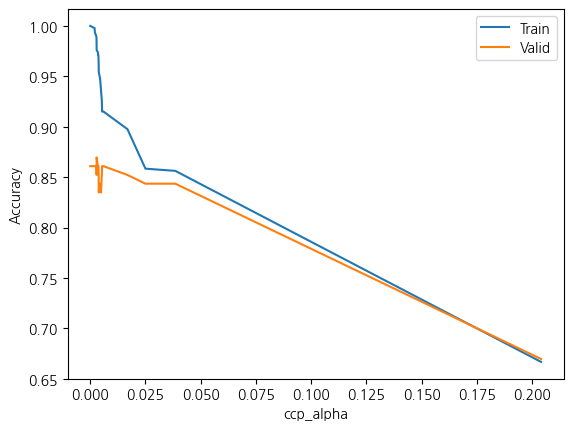

In [111]:
import matplotlib.pyplot as plt

plt.plot(ccp_alphas, train_scores, label='Train')
plt.plot(ccp_alphas, valid_scores, label='Valid')
plt.legend()
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.show()

In [112]:
depth_list = range(1, 31)  # 깊이 1 ~ 30
dt_cross_val_scores = []

for depth in depth_list:
    dt = DecisionTreeClassifier(
        max_depth=depth,
         ccp_alpha=0.025,#가지치기 강도”를 조절하는 하이퍼파라미터
        random_state=42
    )

    scores = cross_val_score(
        dt,
        x_train_data,
        y_train_target,
        cv=6,                  # 6-fold CV
        scoring='accuracy',
        n_jobs=-1
    )

    dt_cross_val_scores.append(scores.mean())

best_depth = depth_list[dt_cross_val_scores.index(max(dt_cross_val_scores))]
best_depth

3

In [113]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
     ccp_alpha=0.025,#가지치기 강도”를 조절하는 하이퍼파라미터
    random_state=42
).fit(x_train_data, y_train_target)
xdtTrain = []
xdtValid = []
for i in range(5):
    xdtTrain.append(dt.score(x_train_data, y_train_target))
    xdtValid.append(dt.score(x_valid_data, y_valid_target))
    print(dt.score(x_train_data, y_train_target))
    print(dt.score(x_valid_data, y_valid_target))

0.8976034858387799
0.8521739130434782
0.8976034858387799
0.8521739130434782
0.8976034858387799
0.8521739130434782
0.8976034858387799
0.8521739130434782
0.8976034858387799
0.8521739130434782


가지치기를 했는데도 과적합이 발생해서 못쓸거같다

In [114]:
print('Train : ',np.mean(dtTrain))
print('Test : ',np.mean(dtTest))

Train :  0.8867595818815331
Test :  0.888888888888889
